In [2]:
# Install dependencies and imports
!pip install open_clip_torch transformers pillow pandas wandb -q

import os
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F
from PIL import Image
from tqdm import tqdm
from huggingface_hub import hf_hub_download
import open_clip

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
Device: cuda


In [ ]:
# Load dataset and define caption conditions
base_path = '/kaggle/input/datasets/egeardaztrk/di725-tp-dataset/DI725_project_dataset'
captions_df = pd.read_csv(f'{base_path}/captions.csv')

print(f"Dataset shape: {captions_df.shape}")
print(f"Columns: {captions_df.columns.tolist()}")

# Define dominant land cover class from composition percentages
class_columns = ['Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water']
class_names = ['Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water']

captions_df['dominant_class'] = captions_df[class_columns].idxmax(axis=1)
captions_df['dominant_class_idx'] = captions_df[class_columns].values.argmax(axis=1)

print("\nClass distribution:")
print(captions_df['dominant_class'].value_counts())

# Correct caption = image's own caption
captions_df['correct_caption'] = captions_df['hybrid_gemma3-4b']

# Misleading caption = randomly sampled caption from an image
# whose dominant class is DIFFERENT from the current image
# This guarantees semantic mismatch while keeping captions natural
np.random.seed(42)

misleading_captions = []
for _, row in captions_df.iterrows():
    current_class = row['dominant_class']
    
    # Get all images with a different dominant class
    different_class_df = captions_df[
        captions_df['dominant_class'] != current_class
    ]
    
    # Randomly pick one caption from that pool
    random_row = different_class_df.sample(1).iloc[0]
    misleading_captions.append(random_row['hybrid_gemma3-4b'])

captions_df['misleading_caption'] = misleading_captions

print("\nMisleading caption definition:")
print("  For each image, caption randomly sampled from images")
print("  with a different dominant land cover class (seed=42)")

print("\nExample verification:")
print(f"Image: {captions_df.iloc[0]['filename']} "
      f"(dominant: {captions_df.iloc[0]['dominant_class']})")
print(f"Correct:    {captions_df.iloc[0]['correct_caption'][:100]}...")
print(f"Misleading: {captions_df.iloc[0]['misleading_caption'][:100]}...")

Dataset shape: (10000, 14)
Columns: ['filename', 'split', 'Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water', 'hybrid_gemma3-4b', 'hybrid_qwen3-vl-8b', 'text_qwen3-4b', 'vision_gemma3-4b', 'vision_qwen3-vl-8b']

Class distribution:
dominant_class
Grass       4703
Tree        3037
Crop        1803
Barren       193
Water        178
Built-up      59
Shrub         27
Name: count, dtype: int64

Misleading caption definition:
  For each image, caption randomly sampled from images
  with a different dominant land cover class (seed=42)

Example verification:
Image: 0073.png (dominant: Grass)
Correct:    The image depicts a landscape dominated by extensive grasslands (92%), with a small area of cultivat...
Misleading: The image depicts a landscape dominated by barren terrain, with a small area of grass covering appro...


In [4]:
# Load CLIP and official RemoteCLIP models

# Loading official RemoteCLIP
print("Downloading RemoteCLIP weights...")
path = hf_hub_download(
    "chendelong/RemoteCLIP",
    filename="RemoteCLIP-ViT-B-32.pt",
    cache_dir="./cache"
)
print(f"Downloaded to: {path}")

print("\nLoading RemoteCLIP...")
model_remoteclip, _, preprocess_remoteclip = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained=path
)
model_remoteclip = model_remoteclip.to(device)
model_remoteclip.eval()
tokenizer_remoteclip = open_clip.get_tokenizer('ViT-B-32')
print("RemoteCLIP loaded")

print("\nLoading CLIP...")
model_clip, _, preprocess_clip = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai'
)
model_clip = model_clip.to(device)
model_clip.eval()
tokenizer_clip = open_clip.get_tokenizer('ViT-B-32')
print("CLIP loaded")

RemoteCLIP-ViT-B-32.pt:   0%|          | 0.00/605M [00:00<?, ?B/s]

Downloaded to: ./cache/models--chendelong--RemoteCLIP/snapshots/bf1d8a3ccf2ddbf7c875705e46373bfe542bce38/RemoteCLIP-ViT-B-32.pt

Loading RemoteCLIP...
RemoteCLIP loaded

Loading CLIP...


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP loaded


In [5]:
# Defining evaluation functions

# Class description templates for zero-shot classification
class_templates = [
    "aerial view of dense tree cover and forest canopy",
    "aerial view of low shrubs and scrubland vegetation",
    "aerial view of open grassland and meadow",
    "aerial view of agricultural cropland and farmland",
    "aerial view of urban buildings and roads",
    "aerial view of barren desert and bare soil",
    "aerial view of river lake or water surface"
]

def get_text_embeddings(model, tokenizer, texts):
    """Encode texts into normalized embeddings."""
    tokens = tokenizer(texts).to(device)
    with torch.no_grad():
        embeds = model.encode_text(tokens)
    return F.normalize(embeds, dim=-1)

def get_image_embeddings(model, preprocess, images):
    """Encode images into normalized embeddings."""
    imgs = torch.stack([preprocess(img) for img in images]).to(device)
    with torch.no_grad():
        embeds = model.encode_image(imgs)
    return F.normalize(embeds, dim=-1)

def load_images(batch, base_path):
    """Load a batch of images from disk."""
    images = []
    for _, row in batch.iterrows():
        img = Image.open(
            f"{base_path}/images/{row['filename']}"
        ).convert("RGB")
        images.append(img)
    return images

def evaluate_zero_shot(model, tokenizer, preprocess, df, 
                        model_name, base_path, batch_size=32):
    """Zero-shot land cover classification accuracy."""
    model.eval()
    correct = 0
    total = 0
    
    text_embeds = get_text_embeddings(model, tokenizer, class_templates)
    
    for i in tqdm(range(0, len(df), batch_size), desc=model_name):
        batch = df.iloc[i:i+batch_size]
        images = load_images(batch, base_path)
        img_embeds = get_image_embeddings(model, preprocess, images)
        
        similarities = (img_embeds @ text_embeds.T)
        predicted = similarities.argmax(dim=-1).cpu().numpy()
        true_labels = batch['dominant_class_idx'].values
        
        correct += (predicted == true_labels).sum()
        total += len(batch)
    
    accuracy = correct / total
    print(f"{model_name} zero-shot accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    return accuracy

def evaluate_caption_similarity(model, tokenizer, preprocess, df,
                                  model_name, base_path, batch_size=32):
    """Average cosine similarity under correct/misleading captions."""
    model.eval()
    correct_sims = []
    misleading_sims = []
    
    for i in tqdm(range(0, len(df), batch_size), desc=model_name):
        batch = df.iloc[i:i+batch_size]
        images = load_images(batch, base_path)
        img_embeds = get_image_embeddings(model, preprocess, images)
        
        correct_embeds = get_text_embeddings(
            model, tokenizer, batch['correct_caption'].tolist()
        )
        misleading_embeds = get_text_embeddings(
            model, tokenizer, batch['misleading_caption'].tolist()
        )
        
        correct_sims.extend(
            (img_embeds * correct_embeds).sum(dim=-1).cpu().numpy()
        )
        misleading_sims.extend(
            (img_embeds * misleading_embeds).sum(dim=-1).cpu().numpy()
        )
    
    results = {
        'correct': float(np.mean(correct_sims)),
        'misleading': float(np.mean(misleading_sims))
    }
    print(f"{model_name} caption similarities: {results}")
    return results

def evaluate_image_only(model, tokenizer, preprocess, df,
                         model_name, base_path, batch_size=32):
    """Image-only baseline: avg max similarity against class templates."""
    model.eval()
    text_embeds = get_text_embeddings(model, tokenizer, class_templates)
    all_max_sims = []
    
    for i in tqdm(range(0, len(df), batch_size), desc=model_name):
        batch = df.iloc[i:i+batch_size]
        images = load_images(batch, base_path)
        img_embeds = get_image_embeddings(model, preprocess, images)
        
        similarities = (img_embeds @ text_embeds.T)
        max_sims = similarities.max(dim=-1).values
        all_max_sims.extend(max_sims.cpu().numpy())
    
    avg_sim = float(np.mean(all_max_sims))
    print(f"{model_name} image-only avg similarity: {avg_sim:.4f}")
    return avg_sim

print("Evaluation functions defined")

Evaluation functions defined


In [7]:
# Run all experiments on full dataset

start_total = time.time()

#  Experiment 1: Image-only baseline 

print("EXPERIMENT 1: Image-only baseline")


start = time.time()
clip_image_only = evaluate_image_only(
    model_clip, tokenizer_clip, preprocess_clip,
    captions_df, 'CLIP', base_path
)
remote_image_only = evaluate_image_only(
    model_remoteclip, tokenizer_remoteclip, preprocess_remoteclip,
    captions_df, 'RemoteCLIP', base_path
)
print(f"Experiment 1 time: {(time.time()-start)/60:.1f} minutes")

#  Experiment 2: Caption similarity 

print("EXPERIMENT 2: Caption similarity under two (misleading and correct) conditions")


start = time.time()
clip_sims = evaluate_caption_similarity(
    model_clip, tokenizer_clip, preprocess_clip,
    captions_df, 'CLIP', base_path
)
remote_sims = evaluate_caption_similarity(
    model_remoteclip, tokenizer_remoteclip, preprocess_remoteclip,
    captions_df, 'RemoteCLIP', base_path
)
print(f"Experiment 2 time: {(time.time()-start)/60:.1f} minutes")

#  Experiment 3: Zero-shot classification 

print("EXPERIMENT 3: Zero-shot land cover classification")

start = time.time()
clip_acc = evaluate_zero_shot(
    model_clip, tokenizer_clip, preprocess_clip,
    captions_df, 'CLIP', base_path
)
remote_acc = evaluate_zero_shot(
    model_remoteclip, tokenizer_remoteclip, preprocess_remoteclip,
    captions_df, 'RemoteCLIP', base_path
)
print(f"Experiment 3 time: {(time.time()-start)/60:.1f} minutes")

print(f"\nTotal experiment time: {(time.time()-start_total)/60:.1f} minutes")

EXPERIMENT 1: Image-only baseline


CLIP: 100%|██████████| 313/313 [03:07<00:00,  1.67it/s]


CLIP image-only avg similarity: 0.2804


RemoteCLIP: 100%|██████████| 313/313 [01:28<00:00,  3.54it/s]


RemoteCLIP image-only avg similarity: 0.2494
Experiment 1 time: 4.6 minutes
EXPERIMENT 2: Caption similarity under two (misleading and correct) conditions


...

RemoteCLIP caption similarities: {'correct': 0.24297304451465607, 'misleading': 0.21880526840686798}
Experiment 2 time: 4.2 minutes
EXPERIMENT 3: Zero-shot land cover classification


CLIP: 100%|██████████| 313/313 [01:27<00:00,  3.57it/s]


CLIP zero-shot accuracy: 0.1713 (17.13%)


RemoteCLIP: 100%|██████████| 313/313 [01:28<00:00,  3.55it/s]

RemoteCLIP zero-shot accuracy: 0.1595 (15.95%)
Experiment 3 time: 2.9 minutes

Total experiment time: 11.7 minutes


In [8]:
# Print results summary

print("RESULTS SUMMARY")


print("\nCaption Similarity Results:")
print(f"{'Model':<15} {'Image-only':>12} {'Correct':>10} {'Misleading':>12}")

print(f"{'CLIP':<15} {clip_image_only:>12.4f} {clip_sims['correct']:>10.4f} {clip_sims['misleading']:>12.4f}")
print(f"{'RemoteCLIP':<15} {remote_image_only:>12.4f} {remote_sims['correct']:>10.4f} {remote_sims['misleading']:>12.4f}")

print(f"\nZero-shot Classification:")
print(f"  CLIP:          {clip_acc:.4f} ({clip_acc*100:.2f}%)")
print(f"  RemoteCLIP:    {remote_acc:.4f} ({remote_acc*100:.2f}%)")
print(f"  Random chance: 14.28% (1/7 classes)")

print(f"\nText bias analysis:")
print(f"  CLIP drop (image-only → misleading):       {clip_image_only - clip_sims['misleading']:.4f}")
print(f"  RemoteCLIP drop (image-only → misleading): {remote_image_only - remote_sims['misleading']:.4f}")

RESULTS SUMMARY

Caption Similarity Results:
Model             Image-only    Correct   Misleading
CLIP                  0.2804     0.2788       0.2663
RemoteCLIP            0.2494     0.2430       0.2188

Zero-shot Classification:
  CLIP:          0.1713 (17.13%)
  RemoteCLIP:    0.1595 (15.95%)
  Random chance: 14.28% (1/7 classes)

Text bias analysis:
  CLIP drop (image-only → misleading):       0.0141
  RemoteCLIP drop (image-only → misleading): 0.0306


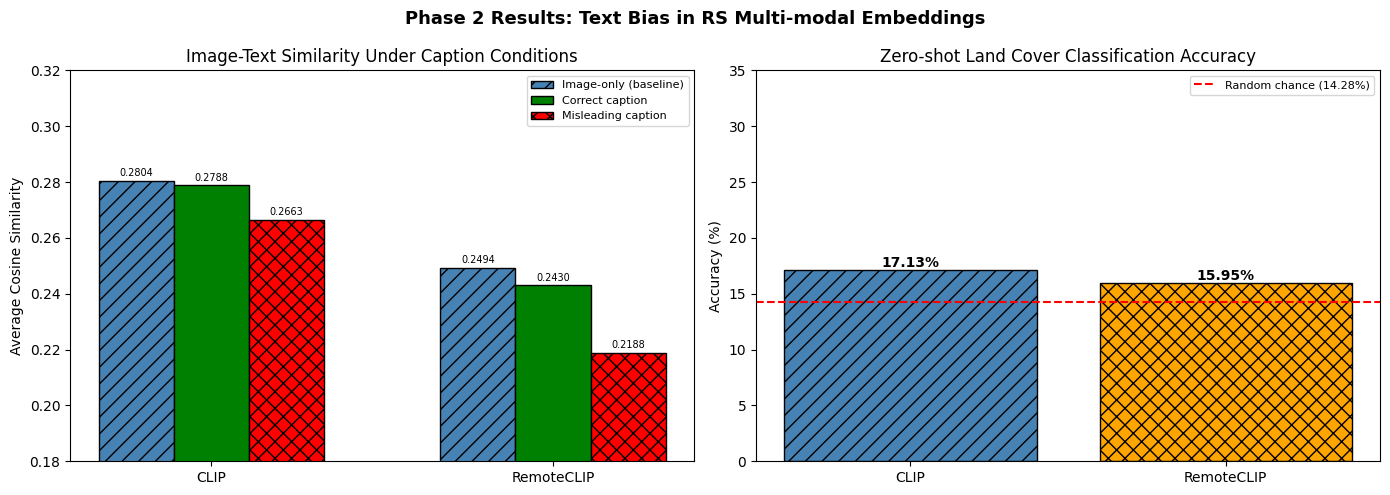

Figure saved to phase2_results.png at 300 dpi


In [ ]:
# Generate results figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['CLIP', 'RemoteCLIP']
image_only_vals = [clip_image_only, remote_image_only]
correct_vals = [clip_sims['correct'], remote_sims['correct']]
misleading_vals = [clip_sims['misleading'], remote_sims['misleading']]

x = np.arange(len(models))
width = 0.22

# Left plot - caption similarity
bars1 = axes[0].bar(x - width, image_only_vals, width,
            label='Image-only (baseline)', color='steelblue',
            edgecolor='black', hatch='//')
bars2 = axes[0].bar(x, correct_vals, width,
            label='Correct caption', color='green',
            edgecolor='black')
bars3 = axes[0].bar(x + width, misleading_vals, width,
            label='Misleading caption', color='red',
            edgecolor='black', hatch='xx')

axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylabel('Average Cosine Similarity')
axes[0].set_title('Image-Text Similarity Under Caption Conditions')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0.18, 0.32)

# Add value labels
for bar in bars1 + bars2 + bars3:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{height:.4f}', ha='center', va='bottom', fontsize=7)

# Right plot - zero-shot classification
accuracies = [clip_acc * 100, remote_acc * 100]
colors = ['steelblue', 'orange']
hatches = ['//', 'xx']
for i, (acc, color, hatch) in enumerate(zip(accuracies, colors, hatches)):
    axes[1].bar(models[i], acc, color=color, 
                edgecolor='black', hatch=hatch)
    axes[1].text(i, acc + 0.3, f'{acc:.2f}%',
                ha='center', fontweight='bold')

axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Zero-shot Land Cover Classification Accuracy')
axes[1].set_ylim(0, 35)
axes[1].axhline(y=14.28, color='red', linestyle='--',
                linewidth=1.5, label='Random chance (14.28%)')
axes[1].legend(fontsize=8)

plt.suptitle('Phase 2 Results: Text Bias in RS Multi-modal Embeddings',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase2_results.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to phase2_results.png at 300 dpi")